# Week 4 — Day 3
## Bias-Variance Trade-off & Diagnosing Model Fit

In this day, we will study how to diagnose model performance by comparing
training and validation scores.

We will focus on:

- Underfitting
- Overfitting
- Bias-Variance Trade-off
- Training vs Validation Score Gap
- Model Complexity
- Regularization

## Objective

The main objective of Day 3 is to understand why a machine learning model
may fail to generalize to unseen data.

We will deliberately create:

1. An underfitting model.
2. An overfitting model.
3. A better-fitting model.

Then, we will compare their training and validation scores to diagnose
the model fit.

Finally, we will study regularization as a method for reducing overfitting.

## Dataset

For this exercise, we use the `BreastCancer.csv` dataset.

The target variable is:

- `Class`

The feature columns are:

- `Cl.thickness`
- `Cell.size`
- `Cell.shape`
- `Marg.adhesion`
- `Epith.c.size`
- `Bare.nuclei`
- `Bl.cromatin`
- `Normal.nucleoli`
- `Mitoses`

The `Id` column is an identifier and is not used as a predictive feature.

This is a classification problem because the model predicts the `Class`
of each observation.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("BreastCancer.csv")

df.head()

,Id,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses,Class
0,1000025,5,1,1,1,2,1.0,3,1,1,0
1,1002945,5,4,4,5,7,10.0,3,2,1,0
2,1015425,3,1,1,1,2,2.0,3,1,1,0
3,1016277,6,8,8,1,3,4.0,3,7,1,0
4,1017023,4,1,1,3,2,1.0,3,1,1,0


In [3]:
df.isnull().sum()

Id                  0
Cl.thickness        0
Cell.size           0
Cell.shape          0
Marg.adhesion       0
Epith.c.size        0
Bare.nuclei        16
Bl.cromatin         0
Normal.nucleoli     0
Mitoses             0
Class               0
dtype: int64

In [5]:
X = df.drop(columns=["Id", "Class"])
y = df["Class"]

In [6]:
X.head()

,Cl.thickness,Cell.size,Cell.shape,Marg.adhesion,Epith.c.size,Bare.nuclei,Bl.cromatin,Normal.nucleoli,Mitoses
0,5,1,1,1,2,1.0,3,1,1
1,5,4,4,5,7,10.0,3,2,1
2,3,1,1,1,2,2.0,3,1,1
3,6,8,8,1,3,4.0,3,7,1
4,4,1,1,3,2,1.0,3,1,1


In [7]:
y.value_counts()

Class
0    458
1    241
Name: count, dtype: int64

## Data Preparation

Before training the models, the dataset must be prepared correctly.

We will:

1. Load the dataset.
2. Handle the `Bare.nuclei` column.
3. Remove rows containing missing values.
4. Separate the features from the target.
5. Remove the `Id` identifier from the features.

The goal is to create clean input data for the experiments.

In [8]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [9]:
print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: (559, 9)
Validation: (140, 9)


## Train/Validation Split

We split the available data into training and validation sets.

The training set is used to train the model, while the validation set is
used to evaluate how well the model generalizes to unseen data during
development.

We use `stratify=y` because this is a classification problem and we want
to preserve the class distribution in both sets.

The validation set will help us diagnose underfitting and overfitting.

## Underfitting Experiment

Underfitting occurs when a model is too simple to capture the important
patterns in the training data.

Typical symptoms are:

- Low training performance.
- Low validation performance.

This corresponds to high bias.

To demonstrate underfitting, we will use a very shallow Decision Tree
with a small `max_depth`.

After training, we will compare its training score with its validation
score.

In [11]:
from sklearn.tree import DecisionTreeClassifier

underfit_model = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)

underfit_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [12]:
train_score_underfit = underfit_model.score(
    X_train,
    y_train
)

train_score_underfit

0.9284436493738819

In [13]:
val_score_underfit = underfit_model.score(
    X_val,
    y_val
)

val_score_underfit

0.9071428571428571

In [14]:
print("Training Score:", train_score_underfit)
print("Validation Score:", val_score_underfit)

Training Score: 0.9284436493738819
Validation Score: 0.9071428571428571


## Underfitting Results

The training and validation scores of the shallow Decision Tree are
compared below.

If both scores are relatively low, the model is underfitting.

This means that the model does not have enough complexity to learn the
patterns present in the data.

The solution is usually to increase model capacity, add useful features,
or use a more powerful model.

In [15]:
overfit_model = DecisionTreeClassifier(
    random_state=42
)

overfit_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [16]:
train_score_overfit = overfit_model.score(
    X_train,
    y_train
)

In [17]:
val_score_overfit = overfit_model.score(
    X_val,
    y_val
)

In [18]:
print("Training Score:", train_score_overfit)
print("Validation Score:", val_score_overfit)

Training Score: 1.0
Validation Score: 0.9285714285714286


## Overfitting Experiment

Overfitting occurs when a model becomes too complex and learns the
training data too closely.

Typical symptoms are:

- Very high training performance.
- Significantly lower validation performance.

This corresponds to high variance.

To demonstrate overfitting, we will train a Decision Tree without
restricting its depth.

We will then compare its training score with its validation score.

## Overfitting Results

The training and validation scores of the unrestricted Decision Tree
are compared below.

A large difference between the two scores indicates that the model is
overfitting.

The model performs very well on the data it has seen during training,
but its performance decreases on unseen validation data.

This indicates that the model has learned the training data too closely
instead of learning patterns that generalize well.

## Bias-Variance Trade-off

The bias-variance trade-off describes the relationship between model
complexity and generalization.

A simple model tends to have:

- Higher bias
- Lower variance

A complex model tends to have:

- Lower bias
- Higher variance

As model complexity increases, bias generally decreases while variance
increases.

The goal is to find a suitable level of complexity where the model is
complex enough to learn meaningful patterns but simple enough to
generalize to unseen data.

In [19]:
depths = [1, 2, 3, 4, 5, 6, 8, 10, None]

train_scores = []
val_scores = []

for depth in depths:
    
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_scores.append(
        model.score(X_train, y_train)
    )
    
    val_scores.append(
        model.score(X_val, y_val)
    )

In [20]:
results = pd.DataFrame({
    "max_depth": depths,
    "train_score": train_scores,
    "validation_score": val_scores
})

results

,max_depth,train_score,validation_score
0,1.0,0.928444,0.907143
1,2.0,0.951699,0.914286
2,3.0,0.969589,0.935714
3,4.0,0.969589,0.928571
4,5.0,0.982111,0.921429
5,6.0,0.987478,0.921429
6,8.0,0.998211,0.935714
7,10.0,1.000000,0.928571
8,NaN,1.000000,0.928571


## Training vs Validation Score Gap

The difference between the training score and validation score is an
important diagnostic tool.

The general interpretation is:

| Training Score | Validation Score | Diagnosis |
|---|---|---|
| Low | Low | Underfitting |
| High | Much lower | Overfitting |
| High | High with a small gap | Good fit |

A small gap between training and validation performance generally indicates
better generalization.

Therefore, we should not judge a model only by its training score.

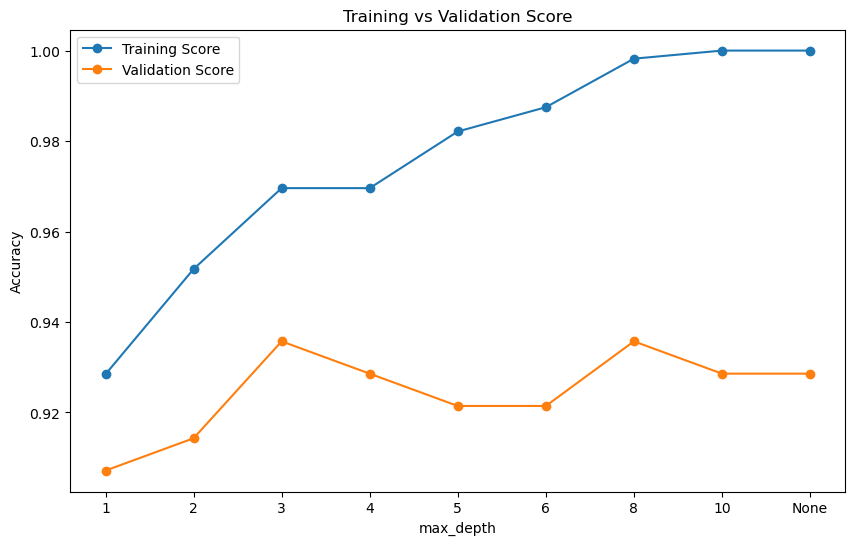

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(len(depths)),
    train_scores,
    marker="o",
    label="Training Score"
)

plt.plot(
    range(len(depths)),
    val_scores,
    marker="o",
    label="Validation Score"
)

plt.xticks(
    range(len(depths)),
    [str(d) for d in depths]
)

plt.xlabel("max_depth")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Score")
plt.legend()
plt.show()

## Model Complexity Experiment

To understand the effect of model complexity, we will train several
Decision Trees using different values of `max_depth`.

For every model, we will record:

- Training score
- Validation score

This allows us to observe how increasing model complexity affects
training performance and validation performance.

The purpose is to identify the point where increasing complexity begins
to hurt generalization.

In [22]:
fixed_model = DecisionTreeClassifier(
    max_depth=4,
    random_state=42
)

fixed_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [23]:
train_score_fixed = fixed_model.score(
    X_train,
    y_train
)

val_score_fixed = fixed_model.score(
    X_val,
    y_val
)

print("Training Score:", train_score_fixed)
print("Validation Score:", val_score_fixed)

Training Score: 0.9695885509838998
Validation Score: 0.9285714285714286


## Training vs Validation Performance

The following visualization compares training and validation performance
for different Decision Tree depths.

The training score generally increases as the model becomes more complex.

However, validation performance may stop improving and can decrease when
the model becomes too complex.

This behavior demonstrates the bias-variance trade-off and helps identify
possible overfitting.

In [24]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

In [25]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

## Fixing Overfitting

The overfitting model can be improved by reducing its complexity.

For the Decision Tree, we can control complexity using `max_depth`.

By limiting the maximum depth, the model is prevented from becoming
unnecessarily complex.

After applying the change, we compare the new training and validation
scores with the original overfitting model.

The goal is to reduce the training-validation gap while maintaining
strong validation performance.

In [26]:
comparison = pd.DataFrame({
    "Model": [
        "Underfitting Tree",
        "Overfitting Tree",
        "Regularized/Simplified Tree"
    ],
    "Training Score": [
        train_score_underfit,
        train_score_overfit,
        train_score_fixed
    ],
    "Validation Score": [
        val_score_underfit,
        val_score_overfit,
        val_score_fixed
    ]
})

comparison

,Model,Training Score,Validation Score
0,Underfitting Tree,0.928444,0.907143
1,Overfitting Tree,1.000000,0.928571
2,Regularized/Simplified Tree,0.969589,0.928571


In [27]:
comparison["Gap"] = (
    comparison["Training Score"]
    - comparison["Validation Score"]
)

comparison

,Model,Training Score,Validation Score,Gap
0,Underfitting Tree,0.928444,0.907143,0.021301
1,Overfitting Tree,1.000000,0.928571,0.071429
2,Regularized/Simplified Tree,0.969589,0.928571,0.041017


## Regularization

Regularization is a technique used to reduce overfitting by penalizing
model complexity.

In linear models, two common forms are:

- Ridge — L2 regularization
- Lasso — L1 regularization

Ridge shrinks model coefficients toward zero.

Lasso can shrink some coefficients exactly to zero, which can also perform
feature selection.

The `alpha` parameter controls the strength of the regularization.

A larger `alpha` applies a stronger penalty and produces a simpler model.

## Model Comparison

We compare the different models using their training and validation
scores.

The comparison helps us determine whether each model is:

- Underfitting
- Overfitting
- Providing a better fit

We also calculate the training-validation gap to support the diagnosis
with numerical evidence rather than relying only on visual inspection.

## Interpretation

The experiments demonstrate that maximizing training performance is not
the main objective.

A model can achieve excellent training performance while performing
poorly on unseen data.

The validation score and the gap between training and validation
performance provide important information about model generalization.

A good model should achieve strong validation performance without an
excessively large training-validation gap.